## 1. Setup & imports

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
import shutil
import json
import random
from collections import Counter

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Config

In [2]:
BDD_ROOT = "/kaggle/input/datasets/solesensei/solesensei_bdd100k"
BDD_LABELS_DIR = os.path.join(BDD_ROOT, "bdd100k_labels_release", "bdd100k", "labels")
BDD_IMAGES_DIR = os.path.join(BDD_ROOT, "bdd100k", "bdd100k", "images", "100k")

WEATHER_LABEL_MAP = {
    "clear": "clear",
    "overcast": "clear",
    "partly cloudy": "clear",
    "rainy": "adverse",
    "snowy": "adverse",
    "foggy": "adverse",
    "undefined": None,
}

TARGET_CLASSES = ["clear", "adverse"]

MAX_PER_CLASS_FROM_BDD = 3000 

LABELED_DIR = "/kaggle/working/weather_labeled"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE_TUNE = 5

ROBOFLOW_API_KEY = "M7b9N8fKVdRTuOBDC6TH"
FOG_ROBOFLOW_WORKSPACE = "srmist-zyr60"
FOG_SOURCES = [
    {"project": "fogdataset", "version": 1},
    {"project": "fog_afmd", "version": None},  
]
FOG_DATA_DIR = "/kaggle/working/fog_supplement"


## 2a. Confirm the mounted paths still resolve

In [3]:
print("BDD_LABELS_DIR:", os.listdir(BDD_LABELS_DIR))
print("BDD_IMAGES_DIR:", os.listdir(BDD_IMAGES_DIR))


BDD_LABELS_DIR: ['bdd100k_labels_images_val.json', 'bdd100k_labels_images_train.json']
BDD_IMAGES_DIR: ['val', 'test', 'train']


## 3. Parse the weather label out of BDD100K's JSON

In [4]:
def load_weather_labels(json_path, images_subdir):
    with open(json_path, "r") as f:
        data = json.load(f)

    entries = []
    for item in data:
        raw_weather = item.get("attributes", {}).get("weather", "undefined")
        mapped = WEATHER_LABEL_MAP.get(raw_weather)
        if mapped is not None:
            entries.append({
                "filename": item["name"],
                "raw_weather": raw_weather,
                "mapped_class": mapped,
                "images_subdir": images_subdir,
            })
    return entries

train_json = os.path.join(BDD_LABELS_DIR, "bdd100k_labels_images_train.json")
val_json = os.path.join(BDD_LABELS_DIR, "bdd100k_labels_images_val.json")

all_entries = []
all_entries += load_weather_labels(train_json, "train")
all_entries += load_weather_labels(val_json, "val")

print(f"Total labeled entries (undefined dropped): {len(all_entries)}")


Total labeled entries (undefined dropped): 70587


## 3a. Check the raw + mapped distribution
Expect `adverse` (rain+snow+fog combined) to land somewhere around 12k raw BDD100K entries before the
existing-file filter in section 4 — still smaller than `clear`, but a real, workable amount now that it's
not split three ways.

In [5]:
raw_counts = Counter(e["raw_weather"] for e in all_entries)
mapped_counts = Counter(e["mapped_class"] for e in all_entries)

print("Raw BDD100K weather tag counts:")
for tag, count in raw_counts.most_common():
    print(f"  {tag}: {count}")

print("\nMapped to our 2 target classes:")
for cls, count in mapped_counts.most_common():
    print(f"  {cls}: {count}")


Raw BDD100K weather tag counts:
  clear: 42690
  overcast: 10009
  snowy: 6318
  rainy: 5808
  partly cloudy: 5619
  foggy: 143

Mapped to our 2 target classes:
  clear: 58318
  adverse: 12269


## 4. Index real files, then cap + copy into class folders
Same fix as last time — check what's ACTUALLY on disk before sampling, since this mirror's `train` split
is mostly missing (only 1,160 real files out of 61,744 referenced; `val` is complete).

In [6]:
random.seed(42)

def index_existing_images():
    existing = {}
    for split in ["train", "val"]:
        split_dir = os.path.join(BDD_IMAGES_DIR, split)
        existing[split] = set(os.listdir(split_dir))
    return existing

existing_files = index_existing_images()

def build_labeled_folders():
    if os.path.exists(LABELED_DIR):
        shutil.rmtree(LABELED_DIR)
    for cls in TARGET_CLASSES:
        os.makedirs(os.path.join(LABELED_DIR, cls), exist_ok=True)

    by_class = {cls: [] for cls in TARGET_CLASSES}
    for e in all_entries:
        if e["filename"] in existing_files[e["images_subdir"]]:
            by_class[e["mapped_class"]].append(e)

    print("Actually available (JSON label AND real file present) per class:")
    for cls, entries in by_class.items():
        print(f"  {cls}: {len(entries)}")

    copied_counts = {cls: 0 for cls in TARGET_CLASSES}
    for cls, entries in by_class.items():
        random.shuffle(entries)
        selected = entries[:MAX_PER_CLASS_FROM_BDD]
        for e in selected:
            src = os.path.join(BDD_IMAGES_DIR, e["images_subdir"], e["filename"])
            dst = os.path.join(LABELED_DIR, cls, e["filename"])
            shutil.copy(src, dst)
            copied_counts[cls] += 1

    print("\nImages copied per class (before fog supplement):")
    for cls, count in copied_counts.items():
        print(f"  {cls}: {count}")

build_labeled_folders()


Actually available (JSON label AND real file present) per class:
  clear: 8108
  adverse: 1752

Images copied per class (before fog supplement):
  clear: 3000
  adverse: 1752


## 5. Supplement `adverse` with SRMIST's fog datasets
Same two sources as before, now copied into the merged `adverse` folder instead of a standalone `fog`
folder.

*** UNVERIFIED: confirm `fog_afmd`'s version number below before running the download cell. ***

In [7]:
!pip install roboflow --quiet
from roboflow import Roboflow

rf_fog = Roboflow(api_key=ROBOFLOW_API_KEY)

for source in FOG_SOURCES:
    project = rf_fog.workspace(FOG_ROBOFLOW_WORKSPACE).project(source["project"])
    print(f"--- {source['project']} versions ---")
    for v in project.versions():
        print(" ", v.version, v.name)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.7 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...
--- fogdataset versions ---
  1 fogdataset
loading Roboflow workspace...
loading Roboflow project...
--- fog_afmd versions ---
  1 fog_afmd


In [8]:
def download_and_copy_fog(project_name, version_number):
    project = rf_fog.workspace(FOG_ROBOFLOW_WORKSPACE).project(project_name)
    version = project.version(version_number)
    location = os.path.join(FOG_DATA_DIR, project_name)
    dataset = version.download("folder", location=location)

    copied = 0
    for split in ["train", "valid", "test"]:
        split_dir = os.path.join(dataset.location, split)
        if not os.path.exists(split_dir):
            continue
        for class_folder in os.listdir(split_dir):
            if "fog" not in class_folder.lower():
                continue  
            class_path = os.path.join(split_dir, class_folder)
            for f in os.listdir(class_path):
                if not f.lower().endswith((".jpg", ".jpeg", ".png")):
                    continue
                src = os.path.join(class_path, f)
                dst = os.path.join(LABELED_DIR, "adverse", f"{project_name}_{split}_{f}")
                shutil.copy(src, dst)
                copied += 1
    print(f"{project_name}: copied {copied} fog images into 'adverse'")
    return copied

total_fog_supplement = 0
for source in FOG_SOURCES:
    if source["version"] is None:
        print(f"Skipping {source['project']} — fill in its version number from the cell above first")
        continue
    total_fog_supplement += download_and_copy_fog(source["project"], source["version"])

print(f"\nTotal supplemental fog images copied: {total_fog_supplement}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /kaggle/working/fog_supplement/fogdataset in folder:: 100%|██████████| 731/731 [00:00<00:00, 6015.23it/s]


fogdataset: copied 368 fog images into 'adverse'
Skipping fog_afmd — fill in its version number from the cell above first

Total supplemental fog images copied: 368


## 5a. Final class counts before training

In [9]:
final_counts = {}
for cls in TARGET_CLASSES:
    cls_dir = os.path.join(LABELED_DIR, cls)
    count = len([f for f in os.listdir(cls_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
    final_counts[cls] = count

print("Final image counts per class:")
for cls, count in final_counts.items():
    print(f"  {cls}: {count}")


Final image counts per class:
  clear: 3000
  adverse: 2120


## 6. Load the dataset for training

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    LABELED_DIR,
    validation_split=0.3,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=TARGET_CLASSES,
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    LABELED_DIR,
    validation_split=0.3,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_names=TARGET_CLASSES,
)

val_batches = tf.data.experimental.cardinality(val_test_ds)
test_ds = val_test_ds.take(val_batches // 2)
val_ds = val_test_ds.skip(val_batches // 2)

print("Class order:", train_ds.class_names)


Found 5120 files belonging to 2 classes.
Using 3584 files for training.


I0000 00:00:1784709318.370669      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784709318.373650      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5120 files belonging to 2 classes.
Using 1536 files for validation.
Class order: ['clear', 'adverse']


## 7. Sanity check — look at labeled images before trusting anything

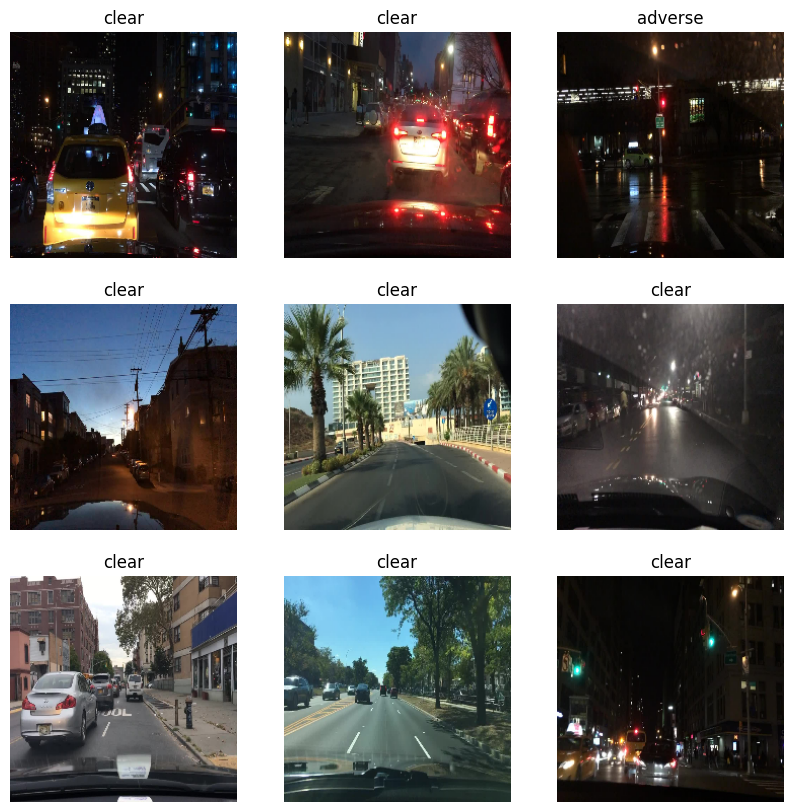

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(TARGET_CLASSES[labels[i]])
        plt.axis("off")
plt.show()


## 8. Data augmentation

In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomBrightness(0.15),
    layers.RandomContrast(0.15),
])


## 9. Build the model — transfer learning on MobileNetV2

In [13]:
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(TARGET_CLASSES), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,260,546 (8.62 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Compute class weights from the real counts

In [14]:
print(train_ds.class_names)

total_images = sum(final_counts[cls] for cls in TARGET_CLASSES)
n_classes = len(TARGET_CLASSES)

class_weight = {
    i: total_images / (n_classes * final_counts[cls])
    for i, cls in enumerate(TARGET_CLASSES)
}

print("Computed class weights:")
for i, cls in enumerate(TARGET_CLASSES):
    print(f"  {cls} (index {i}): {class_weight[i]:.3f}")


['clear', 'adverse']
Computed class weights:
  clear (index 0): 0.853
  adverse (index 1): 1.208


## 11. Compile & train (phase 1 — frozen base)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=3, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop],
    class_weight=class_weight,
)


Epoch 1/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 19s 89ms/step - accuracy: 0.6604 - loss: 0.6567 - val_accuracy: 0.7982 - val_loss: 0.4359
Epoch 2/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.7517 - loss: 0.5211 - val_accuracy: 0.7852 - val_loss: 0.4502
Epoch 3/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.7709 - loss: 0.4850 - val_accuracy: 0.7982 - val_loss: 0.4306
Epoch 4/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.7799 - loss: 0.4602 - val_accuracy: 0.8060 - val_loss: 0.4150
Epoch 5/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.7921 - loss: 0.4432 - val_accuracy: 0.8099 - val_loss: 0.4142
Epoch 6/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - accuracy: 0.7930 - loss: 0.4462 - val_accuracy: 0.7786 - val_loss: 0.4624
Epoch 7/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8025 - loss: 0.4306 - val_accuracy: 0.8177 - val_loss: 0.3943
Epoch 8/10
112/112 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.8078 - loss: 0.4146 - val_acc

## 12. Plot training curves

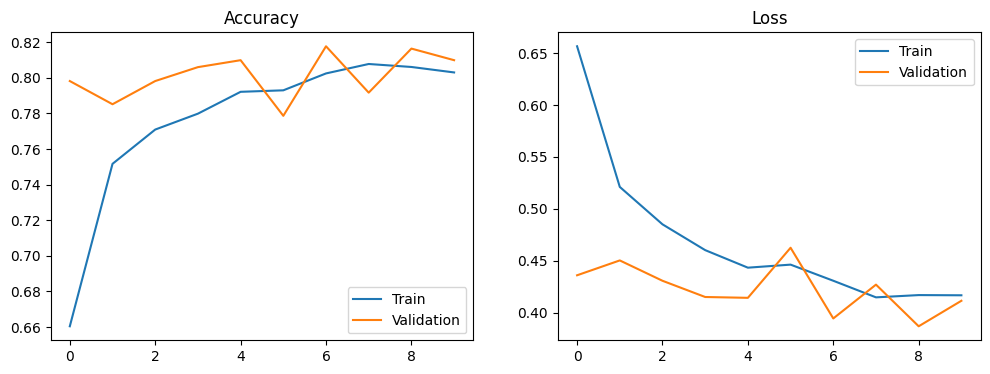

In [16]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train")
plt.plot(epochs_range, val_acc, label="Validation")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train")
plt.plot(epochs_range, val_loss, label="Validation")
plt.legend()
plt.title("Loss")
plt.show()


## 13. Optional phase 2 — fine-tune
Only run this if phase 1 accuracy isn't good enough.

In [17]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=[early_stop],
)


Epoch 1/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 22s 109ms/step - accuracy: 0.7400 - loss: 0.5258 - val_accuracy: 0.8112 - val_loss: 0.4115
Epoch 2/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.8066 - loss: 0.4308 - val_accuracy: 0.8151 - val_loss: 0.3996
Epoch 3/5
112/112 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.8164 - loss: 0.4091 - val_accuracy: 0.8177 - val_loss: 0.3905


## 14. Evaluate on test set + per-class breakdown

In [18]:
test_loss, test_acc = model.evaluate(test_ds)
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))


24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7891 - loss: 0.4544
              precision    recall  f1-score   support

       clear       0.77      0.88      0.82       438
     adverse       0.81      0.65      0.72       330

    accuracy                           0.78       768
   macro avg       0.79      0.77      0.77       768
weighted avg       0.79      0.78      0.78       768



## 15. Actually run this before trusting the model: test on your own photos
Skipped twice already — worth doing this time. Drop a handful of your own clear/rainy/snowy/foggy photos
(windshield-angle if possible) into `/kaggle/working/manual_test/` first.

In [19]:
MANUAL_TEST_DIR = "/kaggle/input/datasets/khawlaelhamdi/testtest"

if os.path.exists(MANUAL_TEST_DIR):
    test_files = [f for f in os.listdir(MANUAL_TEST_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not test_files:
        print(f"{MANUAL_TEST_DIR} exists but has no images yet — add some before running this.")
    for f in test_files:
        img_path = os.path.join(MANUAL_TEST_DIR, f)
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        img_array = tf.keras.utils.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        preds = model.predict(img_array, verbose=0)[0]
        predicted_class = TARGET_CLASSES[np.argmax(preds)]
        confidence = np.max(preds)
        print(f"{f}: predicted={predicted_class} (confidence={confidence:.2f})")
else:
    print(f"Create {MANUAL_TEST_DIR} and drop a few of your own photos in before running this cell.")


images (4).jpeg: predicted=clear (confidence=0.62)
o1.jpeg: predicted=adverse (confidence=1.00)
d5.jpg: predicted=clear (confidence=0.80)
o2.jpeg: predicted=adverse (confidence=0.96)
h1.jpeg: predicted=adverse (confidence=0.64)
d4.jpg: predicted=clear (confidence=0.51)
h3.jpeg: predicted=clear (confidence=0.52)
r2.jpeg: predicted=adverse (confidence=0.97)
UK_50_mph_speed_limit_sign_on_a_single-carriageway.jpg: predicted=adverse (confidence=0.62)
images (8).jpeg: predicted=adverse (confidence=0.94)
r1.jpg: predicted=adverse (confidence=0.54)
o3.jpeg: predicted=adverse (confidence=0.76)
images (5).jpeg: predicted=clear (confidence=0.76)
ui1.jpg: predicted=clear (confidence=0.88)
images (3).jpeg: predicted=adverse (confidence=0.87)


## 16. Export to TensorFlow Lite

In [20]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open("/kaggle/working/weather_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved to /kaggle/working/weather_classifier.tflite — download from the notebook's Output tab.")


INFO:tensorflow:Assets written to: /tmp/tmpfy4m_lrz/assets


INFO:tensorflow:Assets written to: /tmp/tmpfy4m_lrz/assets


Saved artifact at '/tmp/tmpfy4m_lrz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134676638943952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638947408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638947600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638946832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638946064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638944912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638948176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638949136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638948752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134676638946448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1346766389

W0000 00:00:1784709485.597549      23 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1784709485.597591      23 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1784709485.741785      23 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
